# Ablation Study Visualisierung (Week 8)
Hier werten wir die aktuellen Messwerte aus unserer In-Memory AST Ablation Study aus. Es durchläuft die vier konfigurierten Stages (Baseline, Parallel, Cache Block, Combined).
_Hinweis_: Große Modelle wie Einsum werden möglicherweise auf manchen Betriebssystemen (z.B. macOS M-Serie) aufgrund des massiven OOM (Out-of-Memory)-Limits im Terminal-Modus getötet. Das Skript zeigt aber alle erfolgreich evaluierten Matrizen an.

Führe Benchmarks aus (das kann etwas dauern)...
Benchmarks abgeschlossen! Werte aus...


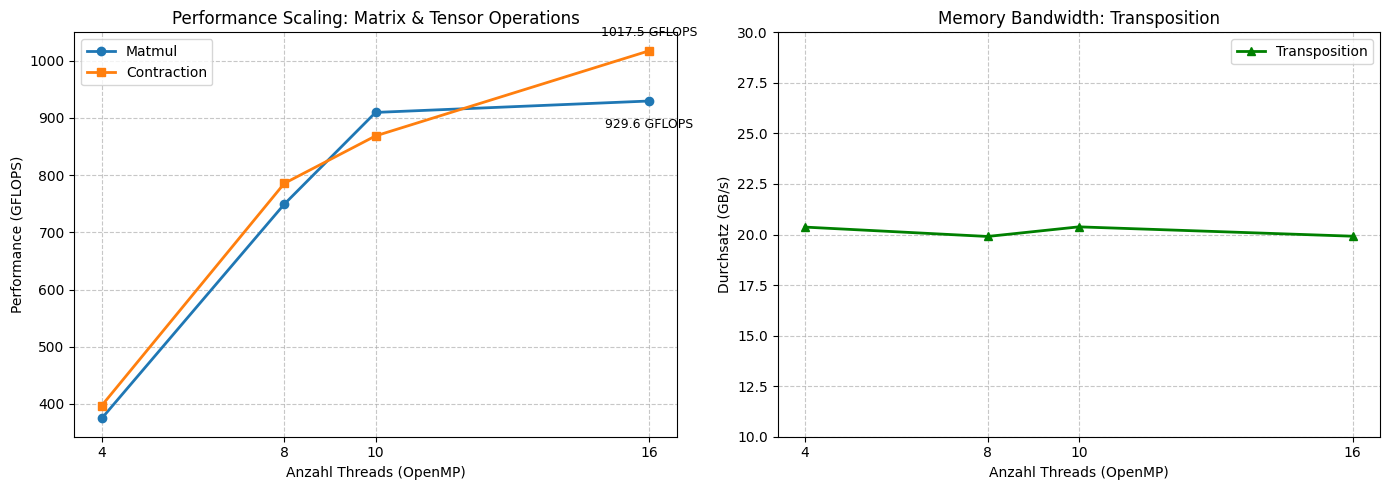

In [ ]:
import subprocess
import re
import matplotlib.pyplot as plt
import numpy as np

print("Führe Benchmarks aus (das kann einen Moment und viel RAM benötigen)...")
# Ausführen der Runtime (im Überordner ../)
result = subprocess.run(["./teir_runtime"], capture_output=True, text=True, cwd="..", errors="ignore")
output = result.stdout

if result.returncode != 0:
    print("Hinweis: Der Prozess wurde vorzeitig beendet (vermutlich OOM durch Einsum-Speicherlimit).")
print("Benchmarks abgeschlossen (oder partiell beendet)! Werte aus...")

models = []
times = {}

current_model = None
current_stage = None

for line in output.split('\n'):
    match_model = re.search(r'Model: (\w+) \(data/', line)
    if match_model:
        current_model = match_model.group(1)
        if current_model not in models:
            models.append(current_model)
            times[current_model] = [0, 0, 0, 0]
            
    match_stage = re.search(r'>> Stage (\d)', line)
    if match_stage:
        current_stage = int(match_stage.group(1))
        
    match_time = re.search(r'Time: ([0-9.]+) ms', line)
    if match_time and current_model is not None and current_stage is not None:
        times[current_model][current_stage] = float(match_time.group(1))
        current_stage = None

valid_models = []
speedups = {}
for m in models:
    t_vals = times[m]
    if t_vals[0] > 0:  # Baseline successfully evaluated
        valid_models.append(m)
        speedups[m] = [
             1.0, 
             t_vals[0]/t_vals[1] if t_vals[1] > 0 else 0,
             t_vals[0]/t_vals[2] if t_vals[2] > 0 else 0,
             t_vals[0]/t_vals[3] if t_vals[3] > 0 else 0
        ]

stages = ["Stage 0\n(Baseline)", "Stage 1\n(Parallel)", "Stage 2\n(Cache Block)", "Stage 3\n(Combined)"]
x = np.arange(len(stages))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, m in enumerate(valid_models):
    offset = (i - len(valid_models)/2 + 0.5) * width
    s_vals = speedups[m]
    rects = ax.bar(x + offset, s_vals, width, label=m.capitalize())
    
    # Text-Annotations (die Speedups auf die Balken pinseln)
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}x',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Speedup relativ zur Baseline')
ax.set_title('Week 8 Ablation Study: Heuristics Speedups')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label="Baseline (1.0x)")

# Y-Achse slightly padding on top for text visibility
ax.set_ylim(0, max([max(s) for s in speedups.values()] + [1.1]) * 1.15)
ax.legend()

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=300)
plt.show()